# St. Patrick's Day 2015 geomagnetic storm case study

This notebook loads a 30-day OMNIWeb window (2015-03-01 through 2015-03-31) around the March 2015 G4-severe geomagnetic storm and reproduces the same time-series visualizations built in `01_exploratory.ipynb`, but for a validated historical event. The storm peaked on 2015-03-17 with a planetary Kp of roughly 8-, making it the largest event of solar cycle 24 and a canonical validation case for anomaly-detection models.

## What a G4 storm looks like in the data

A G4-severe storm is triggered when a coronal mass ejection (CME) launched from the Sun reaches Earth's magnetosphere and its embedded magnetic field couples strongly southward against Earth's field. In near-Earth solar-wind observations (which OMNI2 time-shifts from L1 to the estimated magnetopause arrival), the sequence looks like this:

1. **Shock arrival — a sudden jump.** When the CME-driven interplanetary shock hits, solar-wind **speed** jumps sharply (typically from a quiet ~350 km/s baseline to 500–800 km/s within one hourly sample), **proton density** spikes as the shock compresses the ambient wind, **temperature** rises, and the **IMF magnitude** roughly doubles or triples. This shock signature is unmistakable in an hourly series.
2. **Sheath and ejecta passage.** Behind the shock, the compressed sheath and then the CME ejecta itself pass over Earth for many hours. Density stays elevated; speed remains high; IMF magnitude stays large.
3. **Sustained southward IMF (the geomagnetic trigger).** Kp only climbs to storm levels when the north-south component of the IMF (Bz, not plotted directly here but folded into IMF magnitude) turns and remains southward for hours. Sustained southward Bz opens dayside reconnection with Earth's field and pumps energy into the magnetosphere, driving the Kp index up.
4. **Recovery phase.** Over the following 1–3 days, speed slowly decays back toward the quiet baseline, density normalizes, and Kp steps down through 5, 4, and back to quiet levels.

In the plots below you should see (a) a clean speed/density/IMF jump on 2015-03-17, (b) Kp bars going deep red for a sustained multi-hour window on the 17th and 18th, and (c) a slow decay back to baseline over the last third of March. The storm-vs-quiet statistics at the end of the notebook quantify the shift.

## Setup and data loading

Use `fetch_omniweb_historical` to pull the 30-day window. The loader returns a single UTC-indexed frame with `speed`, `density`, `temperature`, `imf_magnitude`, and `Kp` — the same names used in notebook 01, so the plotting helpers carry over unchanged. Raw OMNIWeb responses are cached under `data/raw/omniweb/` so re-running this notebook is offline-safe.

In [1]:
from datetime import datetime, timezone
from pathlib import Path
import sys

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import pandas as pd

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / 'src').is_dir():
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.data_loader import fetch_omniweb_historical

plt.rcParams.update({
    'figure.dpi': 110,
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'axes.titlesize': 14,
    'axes.labelsize': 11,
    'font.size': 10,
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'grid.color': '#d9d9d9',
    'grid.linewidth': 0.7,
})

WINDOW_START = datetime(2015, 3, 1, tzinfo=timezone.utc)
WINDOW_END = datetime(2015, 3, 31, tzinfo=timezone.utc)
STORM_PEAK = pd.Timestamp('2015-03-17 12:00', tz='UTC')

storm_frame = fetch_omniweb_historical(WINDOW_START, WINDOW_END)
print(f'Records fetched: {len(storm_frame):,}')
print(f'UTC coverage: {storm_frame.index.min()} to {storm_frame.index.max()}')
print(f"Peak Kp in window: {storm_frame['Kp'].max():.2f} at {storm_frame['Kp'].idxmax().isoformat()}")
display(storm_frame.head())

Records fetched: 744
UTC coverage: 2015-03-01 00:00:00+00:00 to 2015-03-31 23:00:00+00:00
Peak Kp in window: 7.70 at 2015-03-17T12:00:00+00:00


,speed,density,temperature,imf_magnitude,Kp
time_tag,,,,,
2015-03-01 00:00:00+00:00,479.0,9.8,225676.0,11.1,5.0
2015-03-01 01:00:00+00:00,484.0,9.1,207869.0,12.6,5.0
2015-03-01 02:00:00+00:00,484.0,8.8,218841.0,10.9,5.0
2015-03-01 03:00:00+00:00,499.0,9.2,243273.0,9.7,5.0
2015-03-01 04:00:00+00:00,523.0,9.6,253940.0,9.0,5.0


## Helpers and analysis views

Reuse the same severity-color mapping and storm-marker helper used in notebook 01. Split the frame into a `plasma_metrics` view (numeric plasma quantities) and a `kp_values` view for plotting parity with the real-time notebook. Kp is repeated on each hourly row by OMNI2, so downsample to the underlying 3-hour cadence before drawing bars to avoid visual double-counting.

In [2]:
def kp_severity_color(value: float) -> str:
    """Map a Kp value to green (0-3), yellow (4-5), or red (6+)."""
    if pd.isna(value):
        return '#bdbdbd'
    if value >= 6:
        return '#d73027'
    if value >= 4:
        return '#f6c344'
    return '#3a9d5d'


def add_storm_peak(axis: plt.Axes, timestamp: pd.Timestamp, label: str) -> None:
    """Draw a single labeled vertical line at the storm peak."""
    axis.axvline(timestamp, color='#8b1a1a', linestyle='--', linewidth=1.3, alpha=0.85, zorder=2)
    axis.annotate(
        label,
        xy=(timestamp, 1.0),
        xycoords=('data', 'axes fraction'),
        xytext=(6, -12),
        textcoords='offset points',
        fontsize=9,
        color='#8b1a1a',
        fontweight='bold',
    )


plasma_metrics = storm_frame[['speed', 'density', 'temperature', 'imf_magnitude']]
# OMNI2 repeats each 3-hour Kp value across three hourly rows; keep one row per
# cadence so the bar chart matches the native Kp reporting cadence.
kp_values = storm_frame['Kp'].dropna().resample('3h').first().dropna()

peak_label = f"St. Patrick's Day peak\nKp={storm_frame['Kp'].max():.1f} at {STORM_PEAK:%b %d %H:%M} UTC"
print(f'Hourly plasma records: {len(plasma_metrics):,}')
print(f'3-hour Kp samples: {len(kp_values):,}')

Hourly plasma records: 744
3-hour Kp samples: 248


## Individual time series

Solar-wind velocity, proton density, and Kp on separate axes, each with the storm peak annotated. The shock arrival on 2015-03-17 is visible as an abrupt jump in both speed and density; the Kp bar chart shows the sustained Kp≥6 window that defines the G4 severity classification.

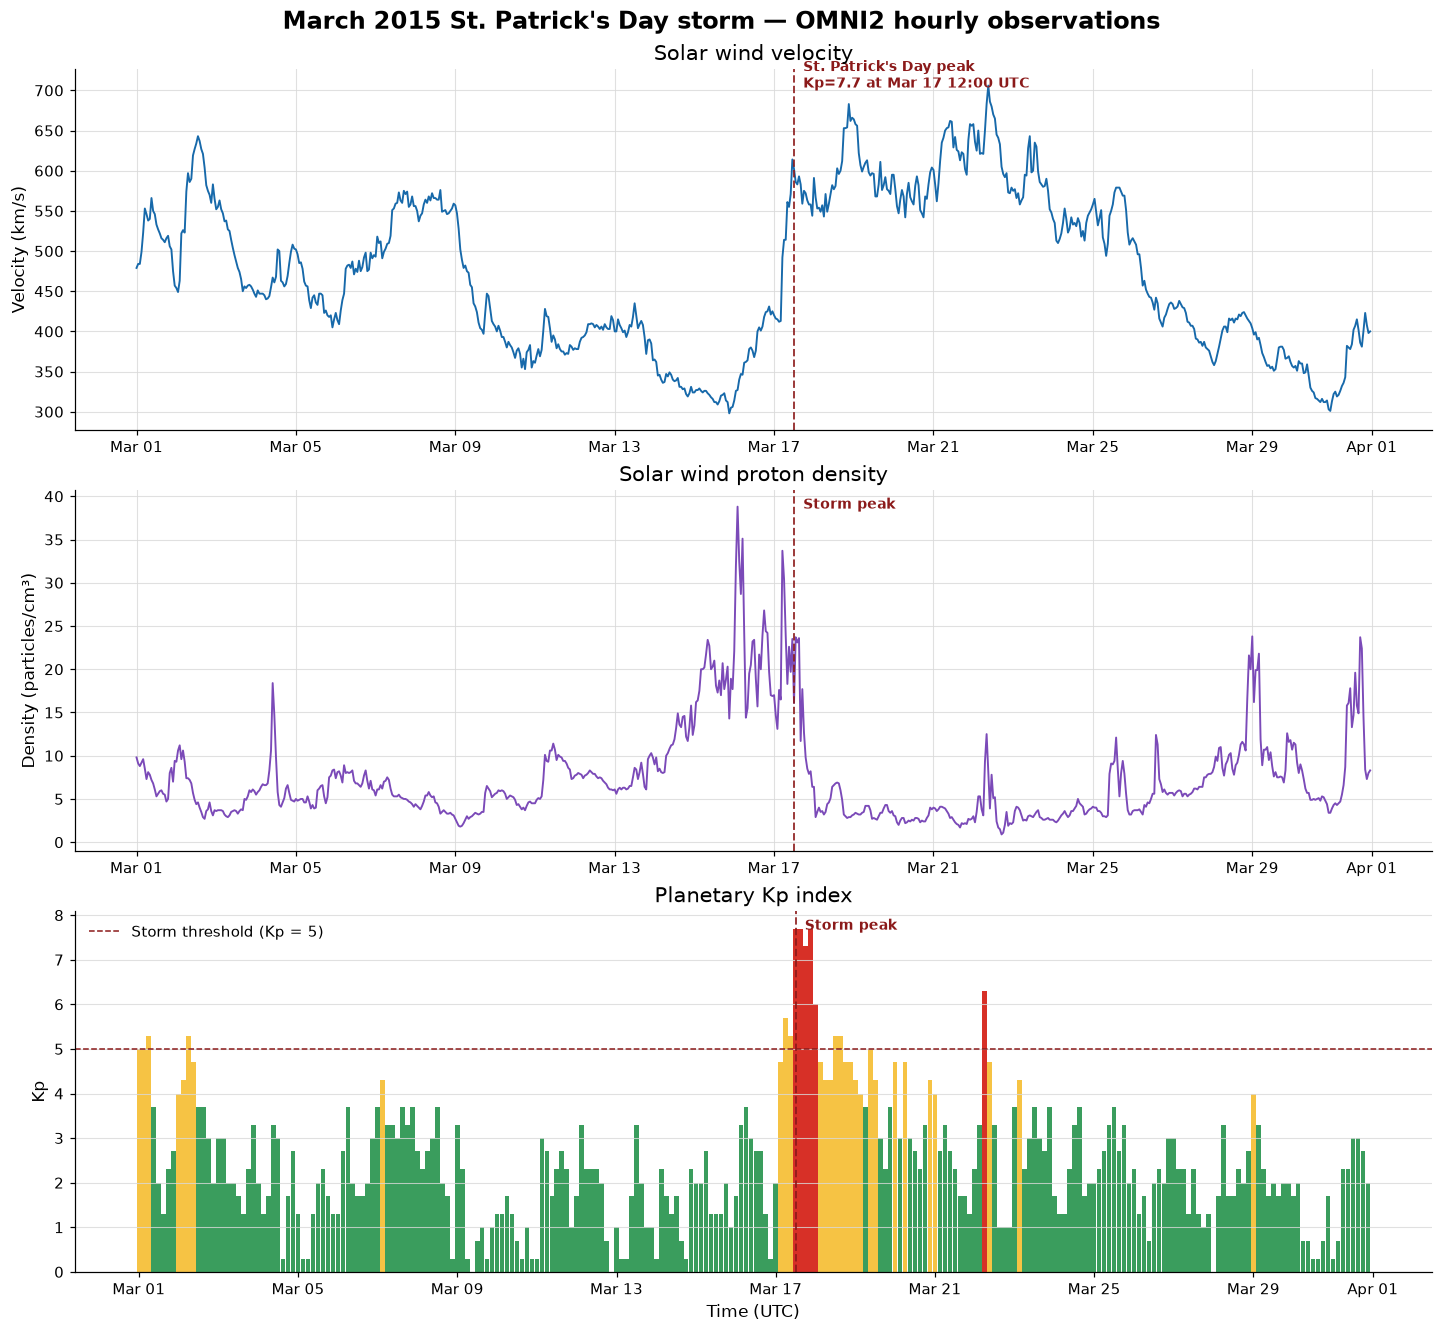

In [3]:
fig, axes = plt.subplots(3, 1, figsize=(13, 12), constrained_layout=True)

axes[0].plot(plasma_metrics.index, plasma_metrics['speed'], color='#1769aa', linewidth=1.25)
add_storm_peak(axes[0], STORM_PEAK, peak_label)
axes[0].set(title='Solar wind velocity', ylabel='Velocity (km/s)')
axes[0].grid(True, alpha=0.8)

axes[1].plot(plasma_metrics.index, plasma_metrics['density'], color='#7b4ab8', linewidth=1.25)
add_storm_peak(axes[1], STORM_PEAK, 'Storm peak')
axes[1].set(title='Solar wind proton density', ylabel='Density (particles/cm³)')
axes[1].grid(True, alpha=0.8)

axes[2].bar(
    kp_values.index,
    kp_values,
    width=pd.Timedelta(hours=2.8),
    color=[kp_severity_color(value) for value in kp_values],
    edgecolor='none',
)
axes[2].axhline(5, color='#8b1a1a', linestyle='--', linewidth=1, label='Storm threshold (Kp = 5)')
add_storm_peak(axes[2], STORM_PEAK, 'Storm peak')
axes[2].set(title='Planetary Kp index', xlabel='Time (UTC)', ylabel='Kp')
axes[2].set_ylim(bottom=0)
axes[2].grid(True, axis='y', alpha=0.8)
axes[2].legend(frameon=False, loc='upper left')

for axis in axes:
    axis.xaxis.set_major_formatter(mdates.DateFormatter('%b %d', tz='UTC'))

fig.suptitle('March 2015 St. Patrick\'s Day storm — OMNI2 hourly observations', fontsize=16, fontweight='bold')
plt.show()

## Combined stacked view

Same three series on a shared time axis. This view makes the causal chain visible: the solar-wind shock (top) arrives first, density spikes (middle), and Kp climbs into red-severity bins (bottom) within hours as sustained southward IMF drives reconnection.

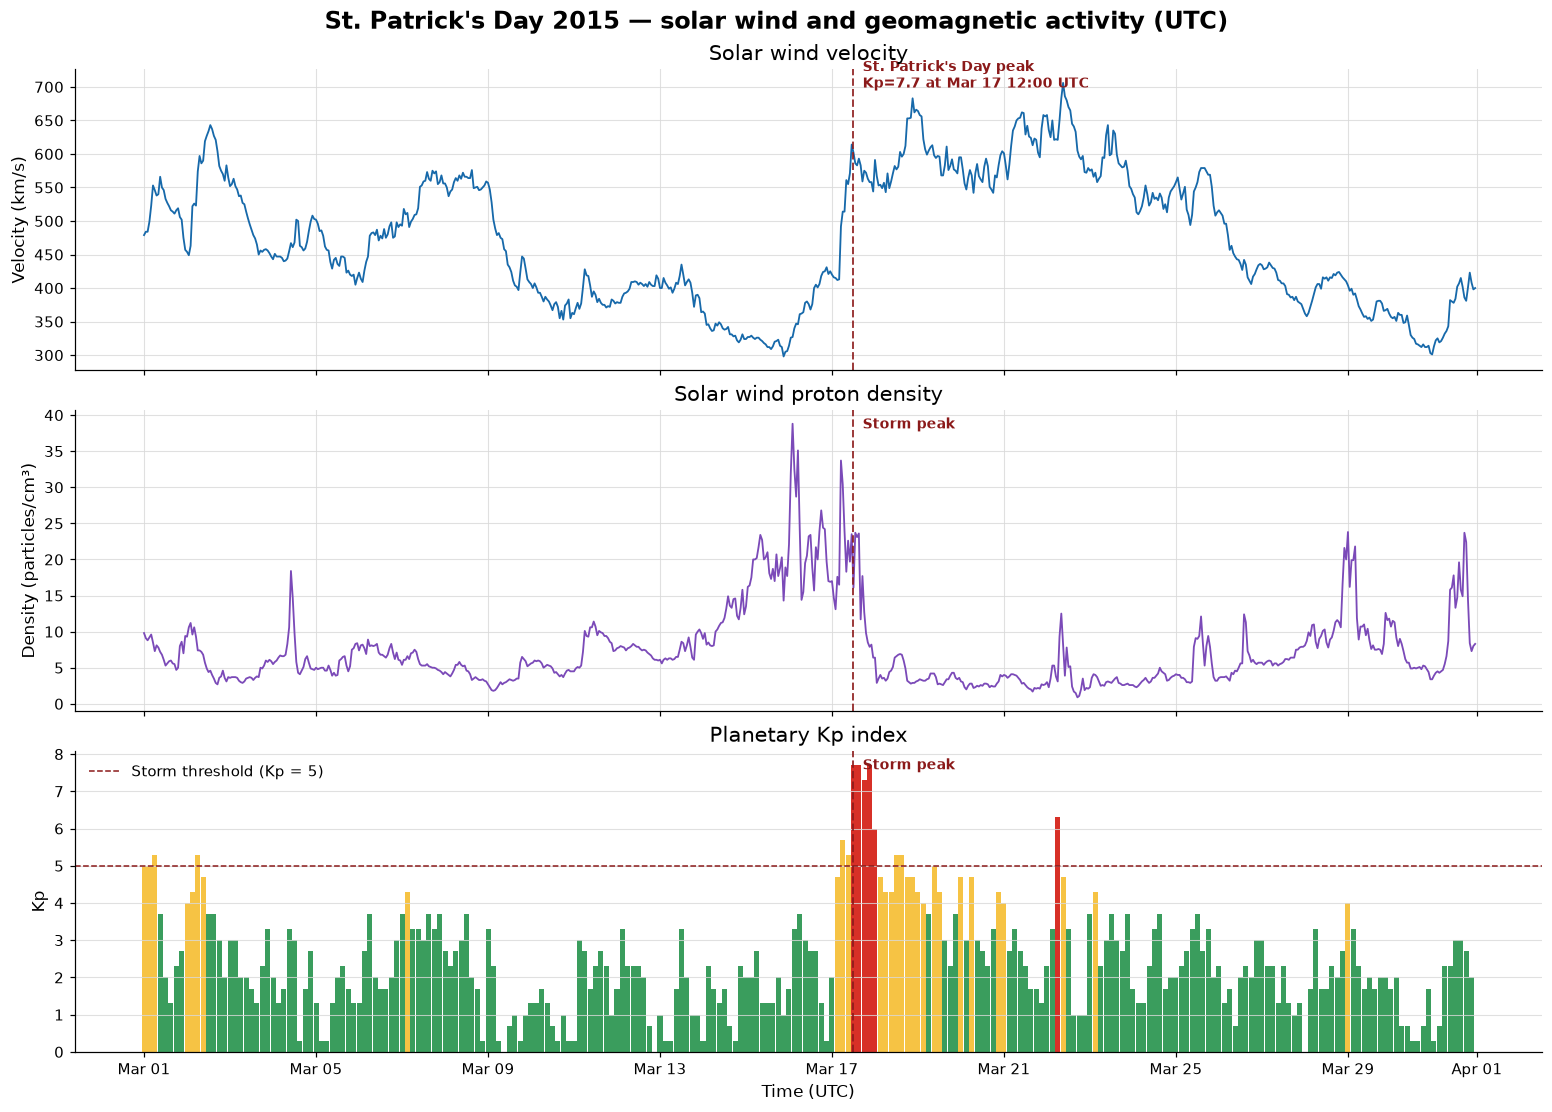

In [4]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True, constrained_layout=True)

series_config = [
    ('speed', 'Solar wind velocity', 'Velocity (km/s)', '#1769aa'),
    ('density', 'Solar wind proton density', 'Density (particles/cm³)', '#7b4ab8'),
]
for axis, (column, title, ylabel, color) in zip(axes[:2], series_config):
    axis.plot(plasma_metrics.index, plasma_metrics[column], color=color, linewidth=1.2)
    add_storm_peak(axis, STORM_PEAK, 'Storm peak' if column == 'density' else peak_label)
    axis.set(title=title, ylabel=ylabel)
    axis.grid(True, alpha=0.8)

axes[2].bar(
    kp_values.index,
    kp_values,
    width=pd.Timedelta(hours=2.8),
    color=[kp_severity_color(value) for value in kp_values],
    edgecolor='none',
)
axes[2].axhline(5, color='#8b1a1a', linestyle='--', linewidth=1, label='Storm threshold (Kp = 5)')
add_storm_peak(axes[2], STORM_PEAK, 'Storm peak')
axes[2].set(title='Planetary Kp index', ylabel='Kp', xlabel='Time (UTC)')
axes[2].set_ylim(bottom=0)
axes[2].grid(True, axis='y', alpha=0.8)
axes[2].legend(frameon=False, loc='upper left')

axes[2].xaxis.set_major_formatter(mdates.DateFormatter('%b %d', tz='UTC'))
fig.suptitle('St. Patrick\'s Day 2015 — solar wind and geomagnetic activity (UTC)', fontsize=16, fontweight='bold')
plt.show()

## Quiet baseline vs storm period statistics

Partition the hourly records into a **quiet baseline** (rows where Kp < 3) and a **storm period** (rows where Kp ≥ 5), then compute mean and standard deviation of velocity and density for each. The ratio of storm to baseline means gives a rough sense of how far off-baseline the storm-period observations sit — the target signal any anomaly detector on this data will need to recover.

In [5]:
quiet_mask = storm_frame['Kp'] < 3
storm_mask = storm_frame['Kp'] >= 5

def summarize(mask: pd.Series, label: str) -> pd.DataFrame:
    subset = storm_frame.loc[mask, ['speed', 'density']]
    return pd.DataFrame({
        'window': label,
        'hours': [len(subset)],
        'speed_mean': [subset['speed'].mean()],
        'speed_std': [subset['speed'].std()],
        'density_mean': [subset['density'].mean()],
        'density_std': [subset['density'].std()],
    })


comparison = pd.concat(
    [summarize(quiet_mask, 'quiet (Kp < 3)'), summarize(storm_mask, 'storm (Kp >= 5)')],
    ignore_index=True,
).set_index('window').round(2)
display(comparison)

quiet_speed = storm_frame.loc[quiet_mask, 'speed'].mean()
storm_speed = storm_frame.loc[storm_mask, 'speed'].mean()
quiet_density = storm_frame.loc[quiet_mask, 'density'].mean()
storm_density = storm_frame.loc[storm_mask, 'density'].mean()
print(f'Storm/quiet speed ratio:   {storm_speed / quiet_speed:.2f}x')
print(f'Storm/quiet density ratio: {storm_density / quiet_density:.2f}x')

,hours,speed_mean,speed_std,density_mean,density_std
window,,,,,
quiet (Kp < 3),483,436.99,86.50,7.46,5.15
storm (Kp >= 5),45,569.58,41.32,10.98,7.00


Storm/quiet speed ratio:   1.30x
Storm/quiet density ratio: 1.47x
